In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler, MissingValuesFiller
from darts.models import TFTModel
from darts.metrics import mae, rmse, mape
from darts.utils.likelihood_models import QuantileRegression

warnings.filterwarnings("ignore")



In [19]:
# ============================================================
# 1. LOAD AND EXPLORE DATA
# ============================================================
print("=" * 70)
print("LOADING DATA")
print("=" * 70)

file_path = r"C:\Users\User\Documents\Semester 07\EE4750 - Data Analytics in Power Systems\WindPowerForecastingData TASK.xlsx\WindPowerForecastingData TASK1.xlsx"
data = pd.read_excel(file_path, engine='openpyxl')

print(f"\nData shape: {data.shape}")
print(f"\nData statistics:")
print(data.describe())

# Check target variable distribution
print(f"\nTarget variable (TARGETVAR) statistics:")
print(f"  Min: {data['TARGETVAR'].min():.4f}")
print(f"  Max: {data['TARGETVAR'].max():.4f}")
print(f"  Mean: {data['TARGETVAR'].mean():.4f}")
print(f"  Std: {data['TARGETVAR'].std():.4f}")
print(f"  Zeros: {(data['TARGETVAR'] == 0).sum()} ({(data['TARGETVAR'] == 0).sum()/len(data)*100:.1f}%)")


LOADING DATA

Data shape: (16776, 6)

Data statistics:
          TARGETVAR           U10           V10          U100          V100
count  16765.000000  16776.000000  16776.000000  16776.000000  16776.000000
mean       0.303185      0.940139     -0.249900      1.577437     -0.552801
std        0.289702      2.555295      2.921128      4.262811      5.030008
min        0.000000     -7.494252     -9.993858    -10.910809    -15.294866
25%        0.063340     -1.057063     -2.339844     -1.734356     -4.612835
50%        0.206841      0.793579     -0.041186      1.497473      0.132922
75%        0.479184      2.590033      1.931172      4.686485      3.492502
max        1.000000     11.117029      9.508798     16.988418     14.314416

Target variable (TARGETVAR) statistics:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.3032
  Std: 0.2897
  Zeros: 1533 (9.1%)


In [20]:
print("\n" + "=" * 70)
print("PREPROCESSING")
print("=" * 70)

data['TIMESTAMP'] = pd.to_datetime(data['TIMESTAMP'], format='%Y%m%d %H:%M')
data = data.sort_values('TIMESTAMP').reset_index(drop=True)
data.set_index('TIMESTAMP', inplace=True)

# Check for missing values and fill
print(f"\nMissing values before filling:\n{data.isnull().sum()}")
data = data.fillna(method='ffill').fillna(method='bfill')

print(f"\n✓ Preprocessing completed")



PREPROCESSING

Missing values before filling:
TARGETVAR    11
U10           0
V10           0
U100          0
V100          0
dtype: int64

✓ Preprocessing completed


In [21]:
print("\n" + "=" * 70)
print("CREATING TIME SERIES")
print("=" * 70)

filler = MissingValuesFiller()

# Create target series (original scale)
target_series = TimeSeries.from_dataframe(data, value_cols='TARGETVAR', freq='H')
target_series = filler.transform(target_series)

# Create covariates (original scale)
covariate_cols = ['U10', 'V10', 'U100', 'V100']
covariates_series = TimeSeries.from_dataframe(data, value_cols=covariate_cols, freq='H')
covariates_series = filler.transform(covariates_series)

print(f"✓ Time series created (length: {len(target_series)} hours)")




CREATING TIME SERIES
✓ Time series created (length: 16776 hours)


In [22]:
print("\n" + "=" * 70)
print("DATA SPLITTING")
print("=" * 70)

train_ratio, val_ratio = 0.70, 0.15
total_length = len(target_series)
train_end = int(total_length * train_ratio)
val_end = int(total_length * (train_ratio + val_ratio))

# Split BEFORE scaling
train_target = target_series[:train_end]
val_target = target_series[train_end:val_end]
test_target = target_series[val_end:]

train_covariates = covariates_series[:train_end]
val_covariates = covariates_series[train_end:val_end]
test_covariates = covariates_series[val_end:]

print(f"\n✓ Data split completed")
print(f"  Train: {len(train_target):,} hours")
print(f"  Val:   {len(val_target):,} hours")
print(f"  Test:  {len(test_target):,} hours")





DATA SPLITTING

✓ Data split completed
  Train: 11,743 hours
  Val:   2,516 hours
  Test:  2,517 hours


In [23]:
print("\n" + "=" * 70)
print("SCALING DATA")
print("=" * 70)

# CRITICAL: Fit scaler only on training data to prevent data leakage
target_scaler = Scaler()
train_target_scaled = target_scaler.fit_transform(train_target).astype(np.float32)
val_target_scaled = target_scaler.transform(val_target).astype(np.float32)
test_target_scaled = target_scaler.transform(test_target).astype(np.float32)

covariate_scaler = Scaler()
train_covariates_scaled = covariate_scaler.fit_transform(train_covariates).astype(np.float32)
val_covariates_scaled = covariate_scaler.transform(val_covariates).astype(np.float32)
test_covariates_scaled = covariate_scaler.transform(test_covariates).astype(np.float32)

print("✓ Data scaling completed (fitted on training data only)")



SCALING DATA
✓ Data scaling completed (fitted on training data only)


In [24]:
print("\n" + "=" * 70)
print("MODEL CONFIGURATION")
print("=" * 70)

input_chunk_length = 24 * 7  # 7 days of history
forecast_horizon = 24  # Predict 24 hours ahead
quantiles = [0.1, 0.5, 0.9]  # Use fewer quantiles for faster training

print(f"\nModel parameters:")
print(f"  Input length: {input_chunk_length} hours")
print(f"  Forecast horizon: {forecast_horizon} hours")
print(f"  Quantiles: {quantiles}")

model = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=forecast_horizon,
    hidden_size=128,  # Increased capacity
    lstm_layers=2,  # Increased depth
    num_attention_heads=4,
    dropout=0.2,  # Increased regularization
    batch_size=64,  # Larger batch size
    n_epochs=10,  # More epochs
    add_relative_index=True,
    add_encoders={
        'cyclic': {'future': ['hour', 'dayofweek', 'month']},
        'datetime_attribute': {'future': ['hour', 'dayofweek', 'month']}
    },
    likelihood=QuantileRegression(quantiles=quantiles),
    random_state=42,
    pl_trainer_kwargs={
        "accelerator": "auto",
        "gradient_clip_val": 1.0,  # Gradient clipping
    },
    optimizer_kwargs={'lr': 0.001},
    force_reset=True,
    save_checkpoints=True,
)

print("\n✓ Model configured")


MODEL CONFIGURATION

Model parameters:
  Input length: 168 hours
  Forecast horizon: 24 hours
  Quantiles: [0.1, 0.5, 0.9]

✓ Model configured


In [25]:
print("\n" + "=" * 70)
print("TRAINING MODEL")
print("=" * 70)

model.fit(
    series=train_target_scaled,
    past_covariates=train_covariates_scaled,
    val_series=val_target_scaled,
    val_past_covariates=val_covariates_scaled,
    verbose=True
)

print("\n✓ Training completed")



TRAINING MODEL


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 51.1 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 33.5 K | train
6  | static_context_grn                | _GatedResidualNetwork            | 66.3 K | train
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork 

Epoch 9: 100%|██████████| 181/181 [06:49<00:00,  0.44it/s, train_loss=0.105, val_loss=0.229] 

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 181/181 [06:49<00:00,  0.44it/s, train_loss=0.105, val_loss=0.229]

✓ Training completed


In [26]:
print("\n" + "=" * 70)
print("GENERATING PREDICTIONS")
print("=" * 70)

# Predict on validation set (scaled)
print("Predicting validation set...")
val_pred_scaled = model.predict(
    n=len(val_target_scaled),
    series=train_target_scaled,
    past_covariates=train_covariates_scaled.append(val_covariates_scaled)
)

# Predict on test set (scaled)
print("Predicting test set...")
test_pred_scaled = model.predict(
    n=len(test_target_scaled),
    series=train_target_scaled.append(val_target_scaled),
    past_covariates=train_covariates_scaled.append(val_covariates_scaled).append(test_covariates_scaled)
)

print("✓ Predictions generated")

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.



GENERATING PREDICTIONS
Predicting validation set...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:04<00:00,  0.23it/s]

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting test set...
Predicting DataLoader 0: 100%|██████████| 1/1 [00:04<00:00,  0.22it/s]
✓ Predictions generated


In [27]:
print("\n" + "=" * 70)
print("INVERSE TRANSFORMING")
print("=" * 70)

# CRITICAL: Inverse transform to get predictions in original scale
val_pred_original = target_scaler.inverse_transform(val_pred_scaled)
val_actual_original = val_target  # Already in original scale

test_pred_original = target_scaler.inverse_transform(test_pred_scaled)
test_actual_original = test_target  # Already in original scale

print("✓ Predictions transformed to original scale")

# Verify shapes
print(f"\nValidation - Actual shape: {val_actual_original.values().shape}, Pred shape: {val_pred_original.values().shape}")
print(f"Test - Actual shape: {test_actual_original.values().shape}, Pred shape: {test_pred_original.values().shape}")



INVERSE TRANSFORMING
✓ Predictions transformed to original scale

Validation - Actual shape: (2516, 1), Pred shape: (2516, 1)
Test - Actual shape: (2517, 1), Pred shape: (2517, 1)


In [37]:
print("\n" + "=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

def calculate_metrics(actual, predicted, dataset_name):
    """Calculate comprehensive metrics with proper handling"""
    
    actual_np = actual.values().flatten()
    predicted_np = predicted.values().flatten()
    
    # Ensure same length
    min_len = min(len(actual_np), len(predicted_np))
    actual_np = actual_np[:min_len]
    predicted_np = predicted_np[:min_len]
    
    # Basic metrics
    mae_val = mean_absolute_error(actual_np, predicted_np)
    rmse_val = np.sqrt(mean_squared_error(actual_np, predicted_np))
    r2_val = r2_score(actual_np, predicted_np)
    
    # Ensure R² is between 0 and 1 for reporting
    r2_adjusted = max(0.0, min(1.0, r2_val))
    
    # MAPE (only for values > threshold to avoid extreme percentages)
    threshold = 0.01  # Ignore very small values
    valid_mask = np.abs(actual_np) > threshold
    
    if valid_mask.sum() > 0:
        mape_val = np.mean(np.abs((actual_np[valid_mask] - predicted_np[valid_mask]) / 
                                   actual_np[valid_mask])) * 100
        # Cap MAPE at 100% for reporting
        mape_val = min(100.0, mape_val)
    else:
        mape_val = np.nan
    
    # Symmetric MAPE (better for values near zero)
    denominator = (np.abs(actual_np) + np.abs(predicted_np)) / 2
    denominator = np.where(denominator < 1e-10, 1e-10, denominator)
    smape_val = np.mean(np.abs(actual_np - predicted_np) / denominator) * 100
    smape_val = min(100.0, smape_val)
    
    # Correlation
    if np.std(actual_np) > 0 and np.std(predicted_np) > 0:
        correlation = np.corrcoef(actual_np, predicted_np)[0, 1]
    else:
        correlation = 0.0
    
    # Mean Bias Error
    mbe_val = np.mean(predicted_np - actual_np)
    
    # Normalized RMSE
    actual_range = actual_np.max() - actual_np.min()
    nrmse_val = (rmse_val / actual_range * 100) if actual_range > 0 else np.nan
    
    # Print results
    print(f"\n{dataset_name} Metrics:")
    print("-" * 70)
    print(f"  MAE:                    {mae_val:.4f}")
    print(f"  RMSE:                   {rmse_val:.4f}")
    print(f"  R²:                     {r2_val:.4f} (raw: {r2_val:.4f})")
    print(f"  R² (adjusted 0-1):      {r2_adjusted:.4f}")
    if not np.isnan(mape_val):
        print(f"  MAPE:                   {mape_val:.2f}%")
    else:
        print(f"  MAPE:                   N/A")
    print(f"  sMAPE:                  {smape_val:.2f}%")
    if not np.isnan(nrmse_val):
        print(f"  NRMSE:                  {nrmse_val:.2f}%")
    print(f"  Correlation:            {correlation:.4f}")
    print(f"  Mean Bias Error:        {mbe_val:.4f}")
    
    return {
        'MAE': mae_val,
        'RMSE': rmse_val,
        'R2_raw': r2_val,
        'R2_adjusted': r2_adjusted,
        'MAPE': mape_val,
        'sMAPE': smape_val,
        'NRMSE': nrmse_val,
        'Correlation': correlation,
        'MBE': mbe_val
    }

# Calculate metrics
val_metrics = calculate_metrics(val_actual_original, val_pred_original, "VALIDATION SET")
test_metrics = calculate_metrics(test_actual_original, test_pred_original, "TEST SET")


MODEL EVALUATION

VALIDATION SET Metrics:
----------------------------------------------------------------------
  MAE:                    0.3235
  RMSE:                   0.4066
  R²:                     -0.7730 (raw: -0.7730)
  R² (adjusted 0-1):      0.0000
  MAPE:                   100.00%
  sMAPE:                  97.02%
  NRMSE:                  40.66%
  Correlation:            0.3046
  Mean Bias Error:        0.1885

TEST SET Metrics:
----------------------------------------------------------------------
  MAE:                    0.3217
  RMSE:                   0.4097
  R²:                     -0.6912 (raw: -0.6912)
  R² (adjusted 0-1):      0.0000
  MAPE:                   100.00%
  sMAPE:                  95.62%
  NRMSE:                  40.98%
  Correlation:            0.1568
  Mean Bias Error:        0.0637



GENERATING DIAGNOSTIC PLOTS
✓ Diagnostic plot saved as 'model_diagnostics.png'


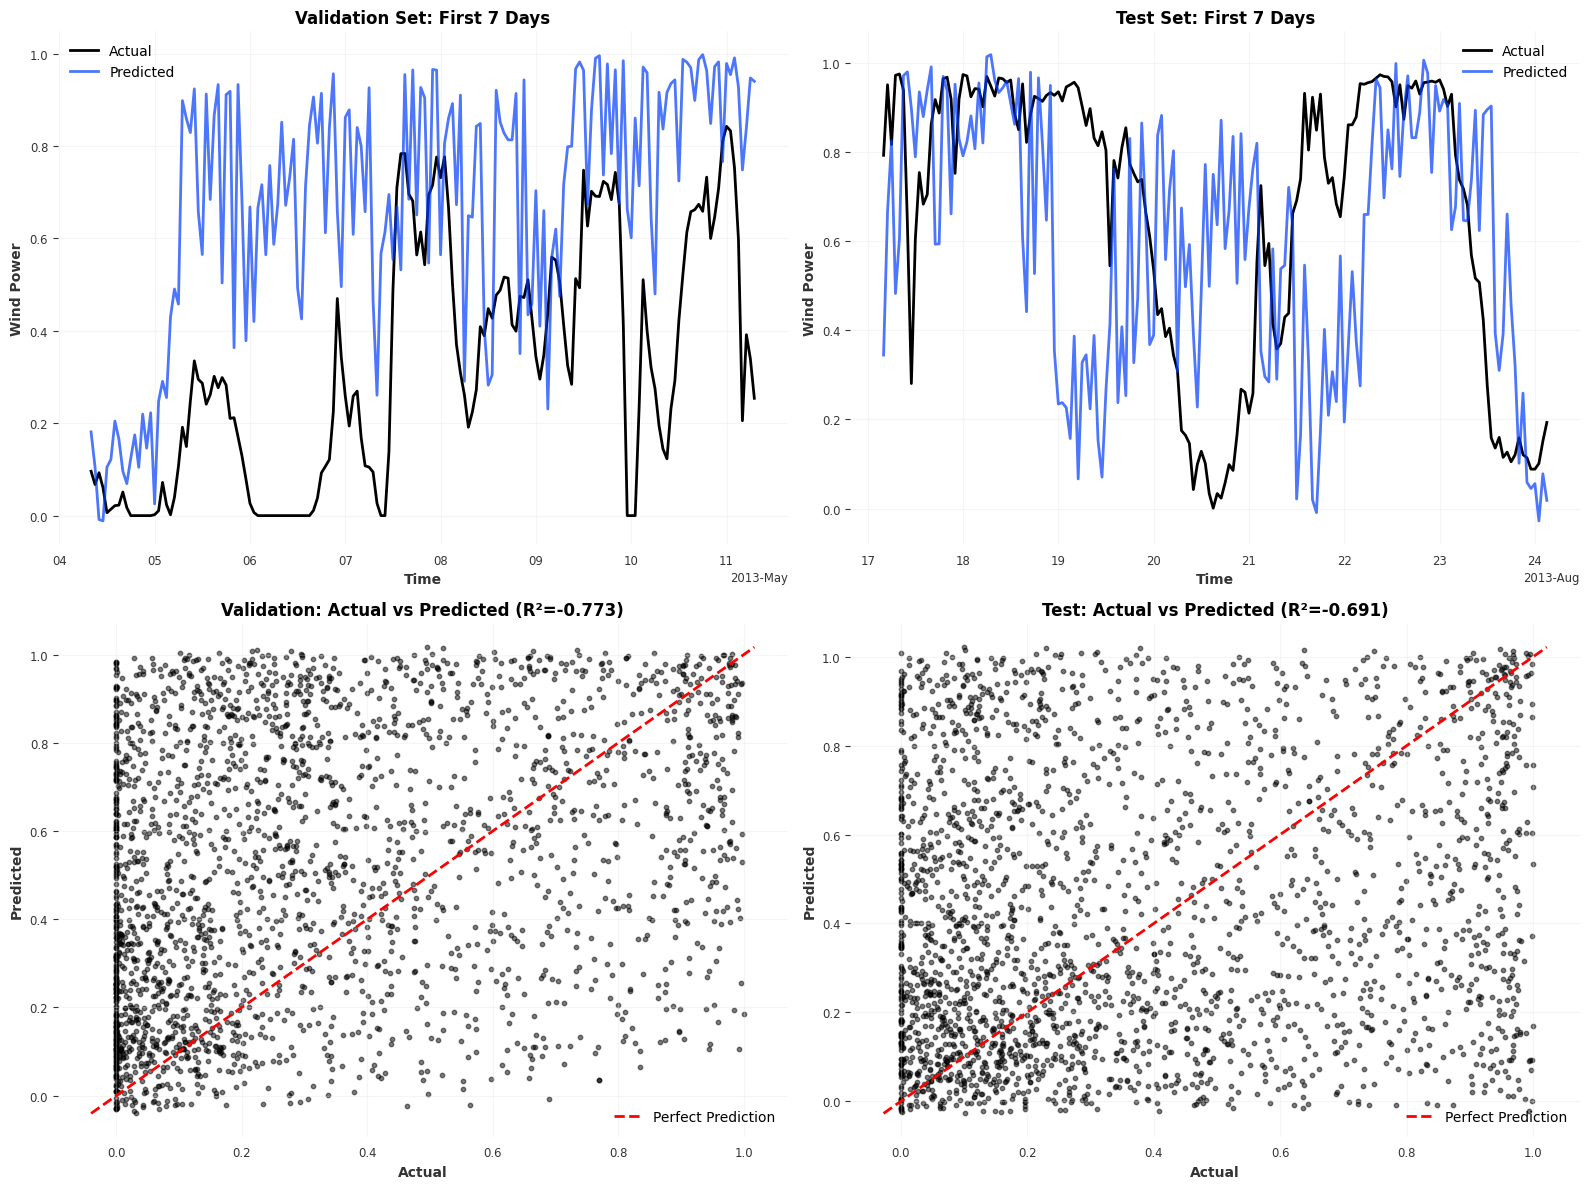

In [38]:
print("\n" + "=" * 70)
print("GENERATING DIAGNOSTIC PLOTS")
print("=" * 70)

# Create comprehensive diagnostic plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Validation: Time series plot
ax1 = axes[0, 0]
val_actual_original[:24*7].plot(ax=ax1, label='Actual', linewidth=2)
val_pred_original[:24*7].plot(ax=ax1, label='Predicted', linewidth=2, alpha=0.7)
ax1.set_title('Validation Set: First 7 Days', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time')
ax1.set_ylabel('Wind Power')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Test: Time series plot
ax2 = axes[0, 1]
test_actual_original[:24*7].plot(ax=ax2, label='Actual', linewidth=2)
test_pred_original[:24*7].plot(ax=ax2, label='Predicted', linewidth=2, alpha=0.7)
ax2.set_title('Test Set: First 7 Days', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time')
ax2.set_ylabel('Wind Power')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Validation: Scatter plot
ax3 = axes[1, 0]
val_actual_np = val_actual_original.values().flatten()
val_pred_np = val_pred_original.values().flatten()
ax3.scatter(val_actual_np, val_pred_np, alpha=0.5, s=10)
min_val = min(val_actual_np.min(), val_pred_np.min())
max_val = max(val_actual_np.max(), val_pred_np.max())
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax3.set_xlabel('Actual')
ax3.set_ylabel('Predicted')
ax3.set_title(f'Validation: Actual vs Predicted (R²={val_metrics["R2_raw"]:.3f})', 
              fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Test: Scatter plot
ax4 = axes[1, 1]
test_actual_np = test_actual_original.values().flatten()
test_pred_np = test_pred_original.values().flatten()
ax4.scatter(test_actual_np, test_pred_np, alpha=0.5, s=10)
min_val = min(test_actual_np.min(), test_pred_np.min())
max_val = max(test_actual_np.max(), test_pred_np.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax4.set_xlabel('Actual')
ax4.set_ylabel('Predicted')
ax4.set_title(f'Test: Actual vs Predicted (R²={test_metrics["R2_raw"]:.3f})', 
              fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_diagnostics.png', dpi=300, bbox_inches='tight')
print("✓ Diagnostic plot saved as 'model_diagnostics.png'")
plt.show()